In [1]:
import numpy as np
import sys 
import sys
sys.path.append('../scripts')
import assembly_tree as at
sys.path.append('../scripts')
import mcmc 
import networkx as nx 
import matplotlib.pyplot as plt 
import numpy as np 
import json
import os
import treelib
import importlib
import copy
#import pandas as pd

importlib.reload(at)

<module 'assembly_tree' from '/Users/glover.co/Documents/laszlo/NetDesign/notebooks/../scripts/assembly_tree.py'>

In [2]:
protein_human_path = '/Users/glover.co/Documents/laszlo/NetDesign/data/proteins/human'


In [3]:
target = nx.read_edgelist(f'{protein_human_path}/edgefiles/CPX-1919.edge', nodetype=int)
X = np.loadtxt(f'{protein_human_path}/Xfiles/X_CPX-1919.txt')
O = at.extract_O(target, X)
capacity = at.extract_deg_cap(target, X).reshape(-1)

In [4]:
initial_tree = mcmc.AssemblyTree(target,X,O,capacity)

In [131]:
initial_tree.update_tree(dist=[.25,.25,0,0,.25,.25])

In [132]:
initial_tree.Tree.show()

0
├── 1
│   ├── 14
│   ├── 15
│   └── 16
├── 2
│   ├── 11
│   └── 12
├── 3
├── 4
├── 5
├── 6
├── 7
├── 8
├── 9
└── 10



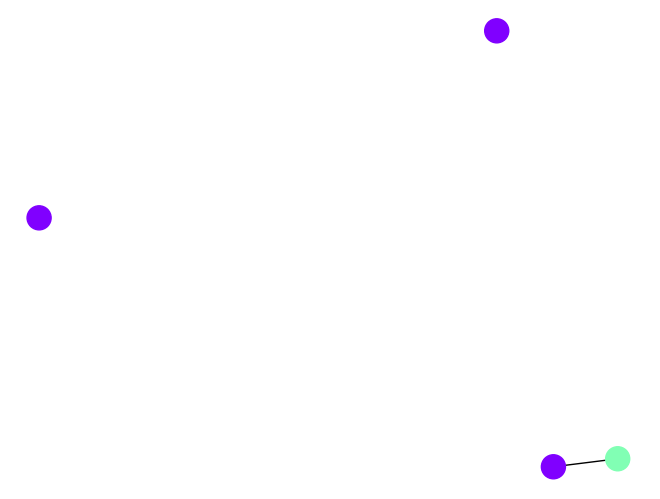

In [137]:
at.draw_network(initial_tree.Tree.get_node(1).data.subgraph[0],initial_tree.X)

In [136]:
initial_tree.Tree.get_node(2).data.p

[np.float64(1.0)]

In [11]:
initial_tree.remove_branching_point(8)

In [16]:
initial_tree.Tree.root

0

In [5]:
Tis = np.ones(1000)
c1q = mcmc.DesignMCMC(initial_tree)


In [6]:
tree_list = [initial_tree]
tree_network = nx.Graph()
tree_dict = {0: copy.deepcopy(initial_tree)}
prev_node = 0
for i in range(1000):
    c1q.run_mcmc(1,[1],dist=[.25,.25,0,0,.25,.25],prior='uniform')
    tree_list.append(copy.deepcopy(c1q.cur_T))
    found = False
    for k, trees in enumerate(tree_dict.values()):
        if c1q.cur_T.Tree.to_dict() == trees.Tree.to_dict():
            if tree_network.has_edge(prev_node, k):
                tree_network[prev_node][k]['weight'] += 1
            else:
                tree_network.add_edge(prev_node, k, weight=1)
            break
    if found:
        prev_node = k
    else:
        tree_network.add_node(len(tree_dict))
        tree_dict[len(tree_dict)] = copy.deepcopy(c1q.cur_T)
        tree_network.add_edge(prev_node, len(tree_dict)-1, weight=1)
        prev_node = len(tree_dict)-1

curp,posterior -6.214608098422191 -688.4729428052196
ac 5.0000000000002024e-297
bestlog -6.214608098422191
curp,posterior -6.214608098422191 -688.4729428052196
ac 5.0000000000002024e-297
bestlog -6.214608098422191
curp,posterior -6.214608098422191 -688.4729428052196
ac 5.0000000000002024e-297
bestlog -6.214608098422191
curp,posterior -6.214608098422191 -688.4729428052196
ac 5.0000000000002024e-297
bestlog -6.214608098422191
curp,posterior -6.214608098422191 -688.4729428052196
ac 5.0000000000002024e-297
bestlog -6.214608098422191
curp,posterior -6.214608098422191 -688.4729428052196
ac 5.0000000000002024e-297
bestlog -6.214608098422191
curp,posterior -6.214608098422191 -688.4729428052196
ac 5.0000000000002024e-297
bestlog -6.214608098422191
curp,posterior -6.214608098422191 -688.4729428052196
ac 5.0000000000002024e-297
bestlog -6.214608098422191
curp,posterior -6.214608098422191 -688.4729428052196
ac 5.0000000000002024e-297
bestlog -6.214608098422191
curp,posterior -6.214608098422191 -68

KeyboardInterrupt: 

In [7]:
len(tree_dict.keys())

28

In [142]:
depths = []
for k, trees in tree_dict.items():
    depths.append(trees.Tree.depth())

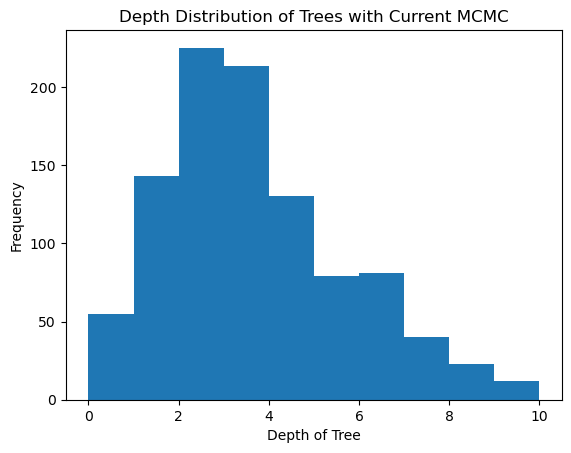

In [143]:
plt.hist(depths)
plt.xlabel('Depth of Tree')
plt.ylabel('Frequency')
plt.title('Depth Distribution of Trees with Current MCMC')
plt.show()

In [13]:
c1q.cur_T.split(0)

In [16]:
c1q.cur_T.add_branching_point(0)

In [21]:
c1q.cur_T.add_branching_point(0)

In [22]:
c1q.cur_T.Tree.show()

0
├── 3
├── 4
├── 5
├── 7
├── 11
├── 12
├── 14
├── 15
├── 17
├── 18
│   ├── 1
│   ├── 2
│   ├── 8
│   ├── 9
│   ├── 10
│   └── 13
└── 19
    ├── 6
    └── 16



In [23]:
nodes = c1q.cur_T.Tree.nodes    

In [36]:
def compare_trees(tree1, tree2):
    tree1_dict = {}
    tree2_dict = {}
    depth1 = tree1.Tree.depth()
    depth2 = tree2.Tree.depth()
    if depth1 != depth2:
        return False
    next_children1 = []
    cur_level1 = [tree1.Tree.root]
    next_children2 = []
    cur_level2 = [tree2.Tree.root]
    for i in range(depth1):
        tree1_dict[i] = cur_level1
        tree2_dict[i] = cur_level2
        # Get number of children for each node at depth
        for j in range(len(cur_level1)):
            children1 = cur_level1[j][1]
            children2 = cur_level2[j][1]
            if len(children1) != len(children2):
                return False
            # Sort children by number of children
            children1.sort(key=lambda x: len(tree1.Tree.get_node(x).data.nodes))
            children2.sort(key=lambda x: len(tree2.Tree.get_node(x).data.nodes))
            next_children1.extend([(tree1.Tree.get_node(children1[k]), tree1.Tree.get_node(children1[k]).data.nodes) for k in range(len(children1))])
            next_children2.extend([(tree2.Tree.get_node(children2[k]), tree2.Tree.get_node(children2[k]).data.nodes) for k in range(len(children2))])
        cur_level1 = next_children1
        cur_level2 = next_children2
        next_children1 = []
        next_children2 = []
    return True

In [37]:
c1q.cur_T.Tree.show()

0
├── 3
├── 4
├── 5
├── 7
├── 11
├── 12
├── 14
├── 15
├── 17
├── 18
│   ├── 1
│   ├── 2
│   ├── 8
│   ├── 9
│   ├── 10
│   └── 13
└── 19
    ├── 6
    └── 16



In [38]:
c1q2 = copy.deepcopy(c1q)

In [39]:
compare_trees(c1q.cur_T, c1q2.cur_T)

TypeError: 'int' object is not subscriptable